# MLP Paper Figures — Extended Diagnostics

This notebook produces the full figure set for the paper using an MLP
regressor with deeper interpretability diagnostics.


In [1]:
import importlib, subprocess, sys
for pkg, spec in [('shap', 'shap'), ('PyALE', 'PyALE')]:
    if importlib.util.find_spec(spec) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('shap and PyALE ready.')

shap and PyALE ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import partial_dependence, permutation_importance

import shap
try:
    from PyALE import ale as pyale
    HAS_PYALE = True
except ImportError:
    HAS_PYALE = False
    print('PyALE not available — ALE cells will be skipped.')

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## Helper Functions

`scatter_with_errors` now accepts an optional `y_vals` argument so it can also
plot corrected residuals in the before/after panels.

In [3]:
nbins = 10
point_kwargs = dict(alpha=0.2, s=50, color='grey', zorder=3)


def scatter_with_errors(ax, xcol, y_vals=None, nbins=10):
    """Scatter + per-point error bars + binned mean.
    y_vals: if None, uses df['residual_centered'].  Pass corrected residuals
    for after-correction panels.
    """
    x    = df[xcol].values
    y    = df['residual_centered'].values if y_vals is None else np.asarray(y_vals)
    yerr = yerr_all.values

    ax.scatter(x, y, **point_kwargs)
    ax.errorbar(x, y, yerr=yerr, fmt='none', ecolor='black',
                elinewidth=0.5, alpha=0.25, zorder=2)
    ax.axhline(0, linestyle='--', color='orange')

    _, bin_edges, binnumber = binned_statistic(x, x, statistic='count', bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    binned_y, binned_yerr = [], []
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan); binned_yerr.append(np.nan); continue
        y_bin = y[in_bin]
        binned_y.append(np.mean(y_bin))
        binned_yerr.append(np.std(y_bin, ddof=1))
    binned_y    = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)
    ax.errorbar(bin_centers[ok], binned_y[ok], yerr=binned_yerr[ok],
                fmt='o', color='blue', markersize=7, capsize=3, zorder=5)


def nmad(y_true, y_pred):
    return 1.4826 * float(np.median(np.abs(np.asarray(y_pred) - np.asarray(y_true))))


print('Helpers defined.')

Helpers defined.


## Data Loading & Quality Cuts

Identical pipeline to all other notebooks in this series.

In [4]:
df = pd.read_csv('ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv')
print(len(df), 'SNe before quality cuts.')
df = df[(df['lccoverage_flag'] == 1) & (df['fitquality_flag'] == 1)]
print(len(df), 'SNe after quality cuts.')

df['SDSS_g_minus_r'] = df['ABSMAG01_SDSS_G'] - df['ABSMAG01_SDSS_R']

clip = sigma_clip(df['residual_centered'], sigma=3, maxiters=1)
df   = df.loc[~clip.mask].reset_index(drop=True)
print(len(df), 'SNe after 3-sigma clip.')

df = df.loc[df['SFR']    <= 2.5].reset_index(drop=True)
df = df.loc[df['DN4000'] >= 0.5].reset_index(drop=True)
df = df.loc[df['AGE']    >= 2  ].reset_index(drop=True)
print(len(df), 'SNe after physical host-galaxy cuts.')

yerr_all = df['sigma_mu_meas'].copy()

776 SNe before quality cuts.
579 SNe after quality cuts.
563 SNe after 3-sigma clip.
550 SNe after physical host-galaxy cuts.


## Train MLP Model

- **MLP**: skopt best-found hyperparameters, wrapped in a `StandardScaler` pipeline.
- **Cross-val predictions** (`yoos_mlp`): each SN gets an out-of-sample prediction via
  5-fold CV so the before/after correction figures are not inflated by training-set
  memorisation.


In [5]:
feature_cols = [
    'LOGMSTAR', 'c', 'x1', 'SFR', 'VDISP',
    'DN4000', 'SDSS_g_minus_r', 'AGE', 'redshift',
]
target_col = 'residual_centered'

X = df[feature_cols].copy()
y = df[target_col].copy()

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=SEED
)

# ── MLP Pipeline (skopt best params) ─────────────────────────────────────────
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation='tanh', solver='adam',
        alpha=0.4489379023123383,
        learning_rate_init=0.005995964127756074,
        max_iter=2000, early_stopping=False,
        random_state=SEED,
    )),
])
mlp_pipe.fit(Xtr, ytr)
yhat_mlp_te  = mlp_pipe.predict(Xte)
yhat_mlp_all = mlp_pipe.predict(X)

# ── Out-of-sample (cross-val) predictions — used in Fig 4, mass step, cond hists ─
yoos_mlp = cross_val_predict(mlp_pipe, X, y, cv=5)
y_corr_mlp = y.values - yoos_mlp

print('MLP model trained.')
print(f'MLP test R²  : {r2_score(yte, yhat_mlp_te):.4f}')


MLP model trained.
MLP test R²  : 0.6780


---
## Figure 1 — Data / Motivation

2×4 grid of Δμ vs each host-galaxy feature.  A linear fit is overlaid on every
panel so the reader can see the residual trend before any ML correction, and can
later compare where the PD curves (Fig 3) deviate from linearity.

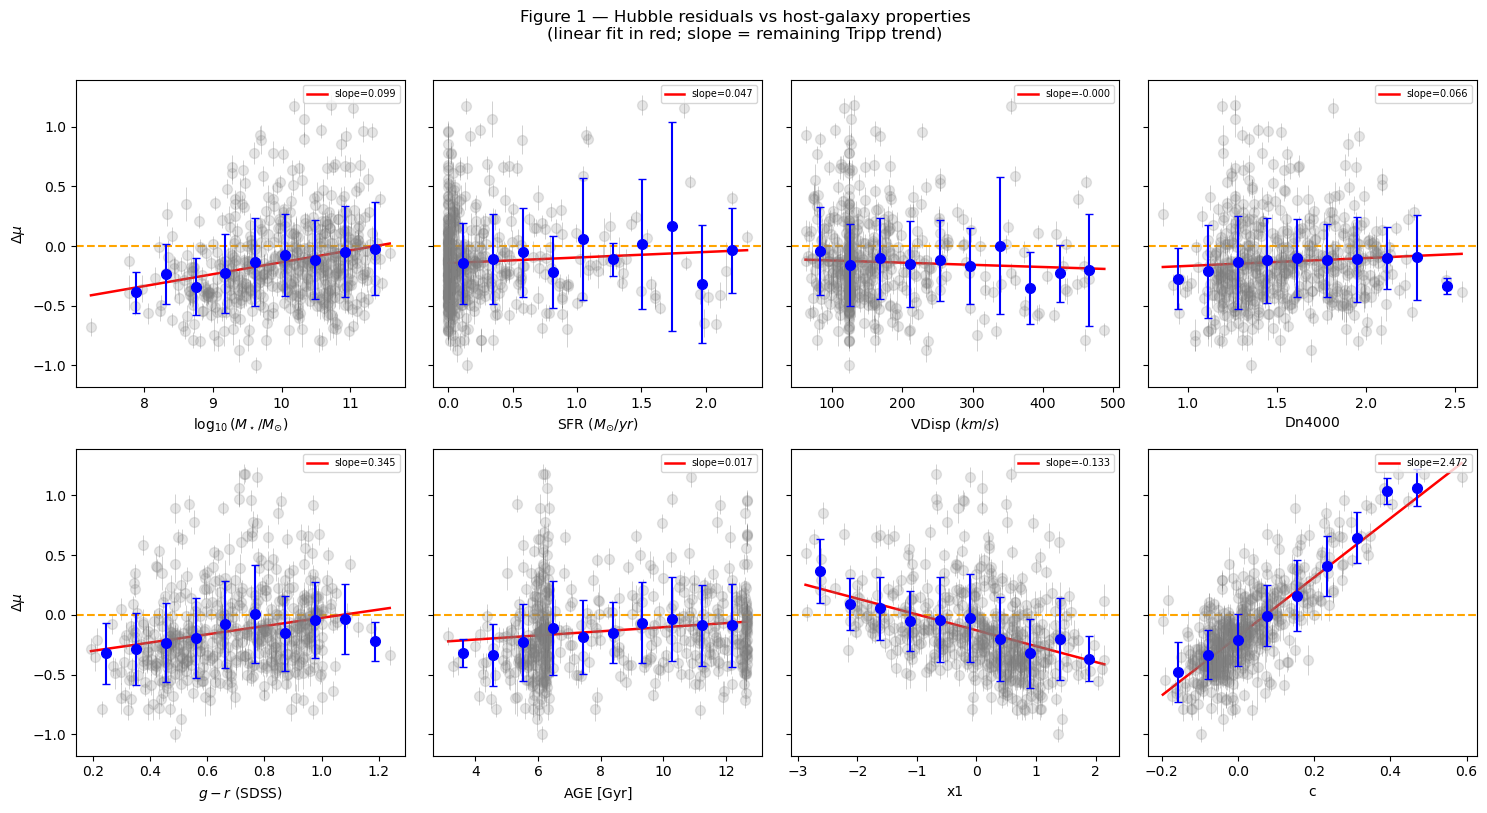

In [6]:
feat_labels = [
    (r'$\log_{10}(M_\star / M_{\odot})$', 'LOGMSTAR'),
    (r'${\rm SFR}\ (M_{\odot}/yr)$',       'SFR'),
    (r'${\rm VDisp}\ (km/s)$',             'VDISP'),
    (r'${\rm Dn4000}$',                    'DN4000'),
    (r'$g - r\ {\rm (SDSS)}$',            'SDSS_g_minus_r'),
    (r'${\rm AGE}\ [{\rm Gyr}]$',          'AGE'),
    ('x1',                                 'x1'),
    ('c',                                  'c'),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, (label, col) in zip(axes, feat_labels):
    scatter_with_errors(ax, col, nbins=nbins)
    # linear reference line
    xv = df[col].values
    yv = y.values
    coef = np.polyfit(xv, yv, 1)
    xfit = np.linspace(xv.min(), xv.max(), 200)
    ax.plot(xfit, np.polyval(coef, xfit), color='red', lw=1.8,
            label=f'slope={coef[0]:.3f}')
    ax.set_xlabel(label)
    ax.legend(fontsize=7, loc='upper right')

axes[0].set_ylabel(r'$\Delta\mu$')
axes[4].set_ylabel(r'$\Delta\mu$')
fig.suptitle('Figure 1 — Hubble residuals vs host-galaxy properties\n'
             '(linear fit in red; slope = remaining Tripp trend)', y=1.01)
fig.tight_layout()
plt.show()

---
## Figure 2 — Feature Importance

Permutation importance for the MLP, scored by negative MAE on the held-out
test set with 30 repeats.  The bar chart shows which host properties carry
the most predictive power.


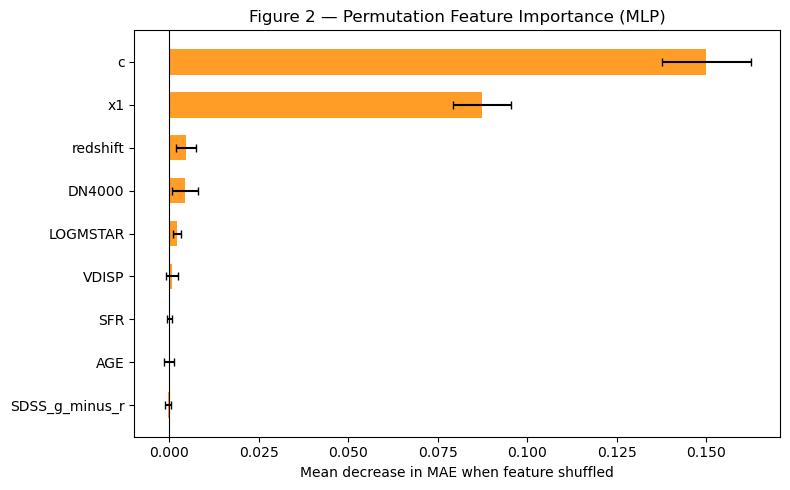

In [7]:
perm_mlp = permutation_importance(
    mlp_pipe, Xte, yte, n_repeats=30, random_state=SEED,
    scoring='neg_mean_absolute_error',
)

fi_mlp = pd.Series(perm_mlp.importances_mean, index=feature_cols)
fi_err = pd.Series(perm_mlp.importances_std, index=feature_cols)

order = fi_mlp.sort_values(ascending=True).index
fi_mlp = fi_mlp.loc[order]
fi_err = fi_err.loc[order]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(feature_cols))

ax.barh(y_pos, fi_mlp.values, 0.6, color='darkorange', alpha=0.85,
        xerr=fi_err.values, capsize=3, label='MLP')

ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean decrease in MAE when feature shuffled')
ax.set_title('Figure 2 — Permutation Feature Importance (MLP)')
fig.tight_layout()
plt.show()


---
## Figure 3 — Partial Dependence Plots

Key changes relative to the base notebook:
- **Redshift-cut inconsistency fixed**: the PD is now evaluated on the full dataset,
  consistent with what the model was trained on.
- **Linear reference line** added per panel (same red line as Fig 1) so the reader
  can see exactly where the MLP curve diverges from a Tripp-like linear correction.


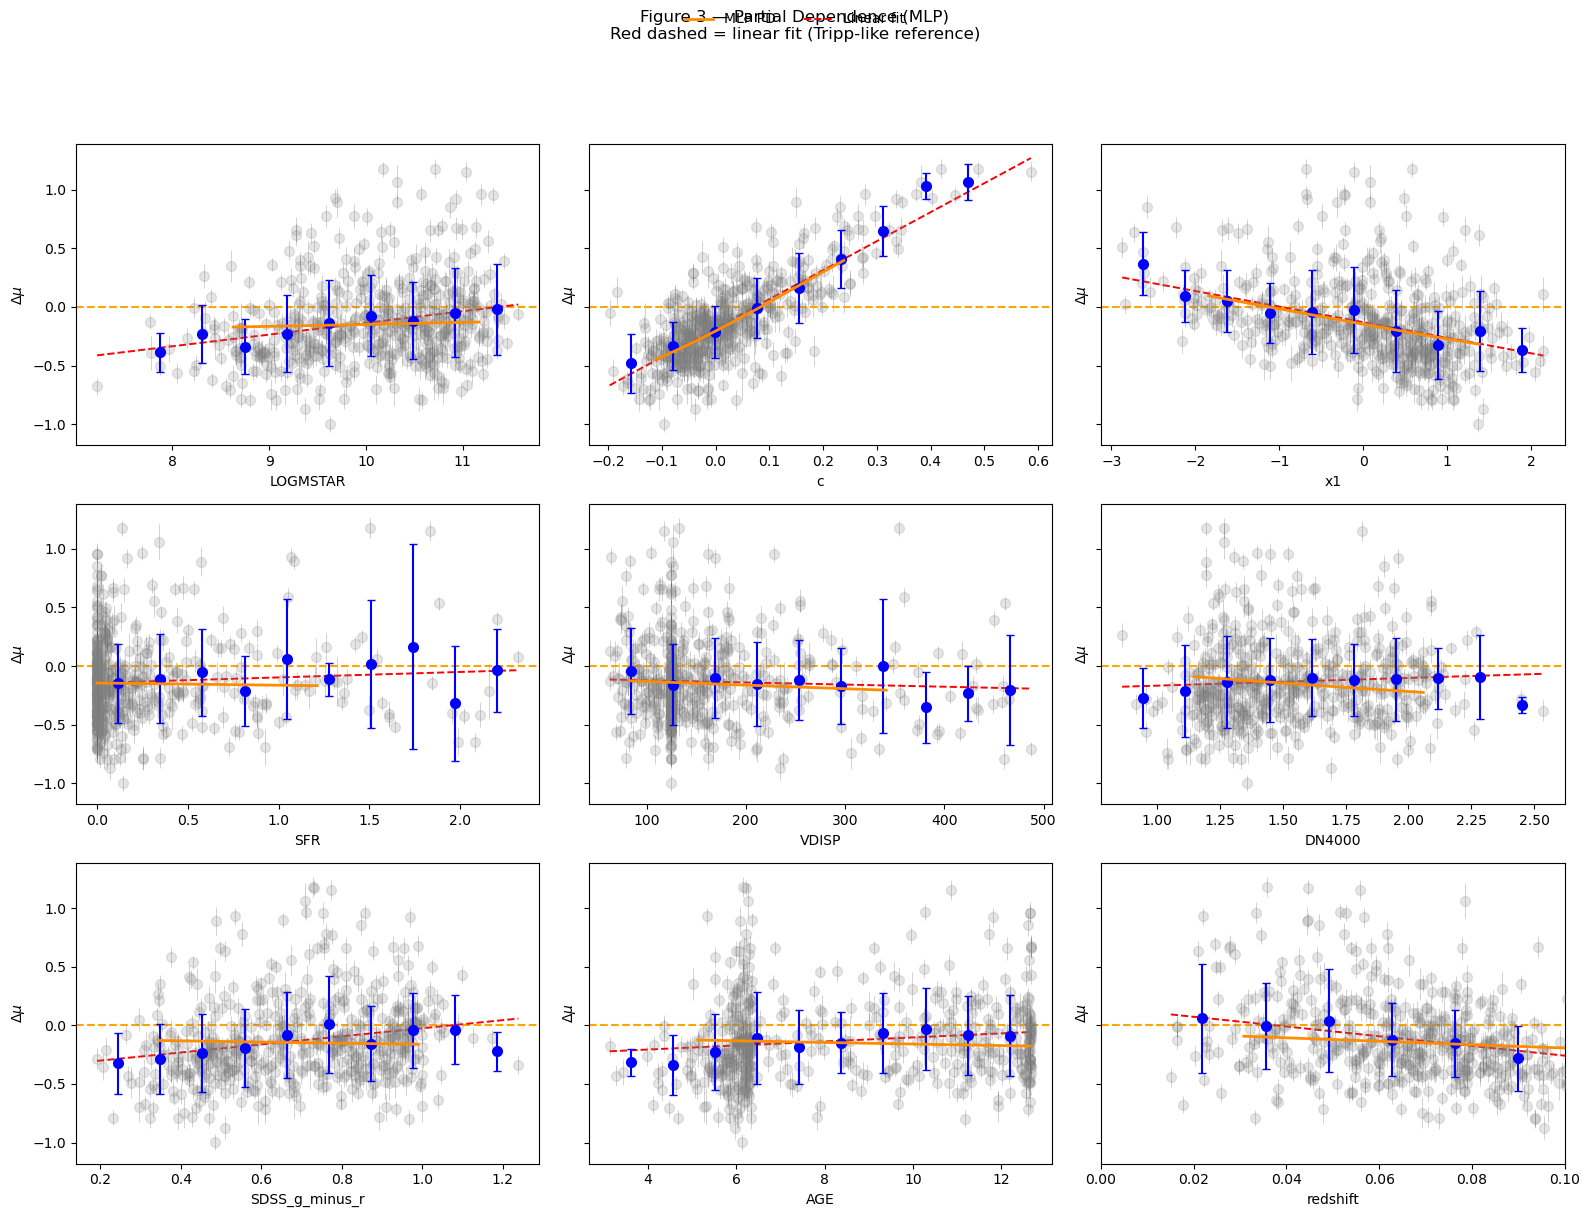

In [8]:
def pd_panel(ax, feature, nbins=10):
    """Plot raw data + binned overlay + PD for MLP."""
    X_pd = X[feature_cols]   # full dataset, no extra redshift cut

    # MLP PD (brute force = literal definition)
    res_mlp = partial_dependence(mlp_pipe, X_pd, features=[feature], method='brute')
    xg_mlp, yg_mlp = res_mlp['grid_values'][0], res_mlp['average'][0]

    # Raw data + binned means
    scatter_with_errors(ax, feature, nbins=nbins)

    # PD curve
    ax.plot(xg_mlp, yg_mlp, color='darkorange', lw=2.0, label='MLP PD', zorder=6)

    # Linear reference (same as Fig 1)
    xv   = df[feature].values
    yv   = y.values
    coef = np.polyfit(xv, yv, 1)
    xfit = np.linspace(xv.min(), xv.max(), 200)
    ax.plot(xfit, np.polyval(coef, xfit), color='red', lw=1.4,
            linestyle='--', label='Linear fit')

    ax.set_xlabel(feature)
    ax.set_ylabel(r'$\Delta\mu$')


fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharey=True)

for ax, col in zip(axes.flatten(), feature_cols):
    kw = dict(nbins=20) if col == 'redshift' else dict(nbins=nbins)
    pd_panel(ax, col, **kw)
    if col == 'redshift':
        ax.set_xlim(0, 0.1)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Figure 3 — Partial Dependence (MLP)\n'
             'Red dashed = linear fit (Tripp-like reference)', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


---
## Figure 4 — Before/After Scatter Reduction

Out-of-sample corrected residuals are used here (`yoos_mlp` from 5-fold CV) so
the scatter reduction is not artificially inflated by training-set memorisation.

`y_corr = Δμ − ŷ_oos` — after subtracting the MLP-predicted host bias,
the corrected residuals should be narrower and show flatter trends.


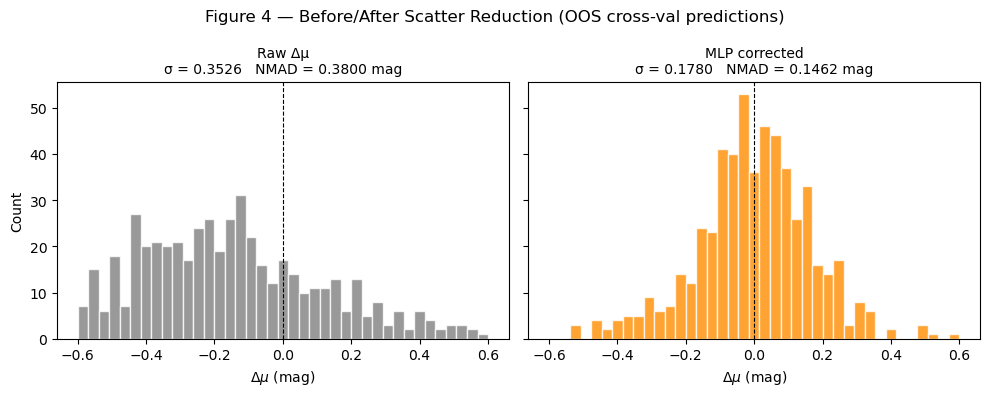

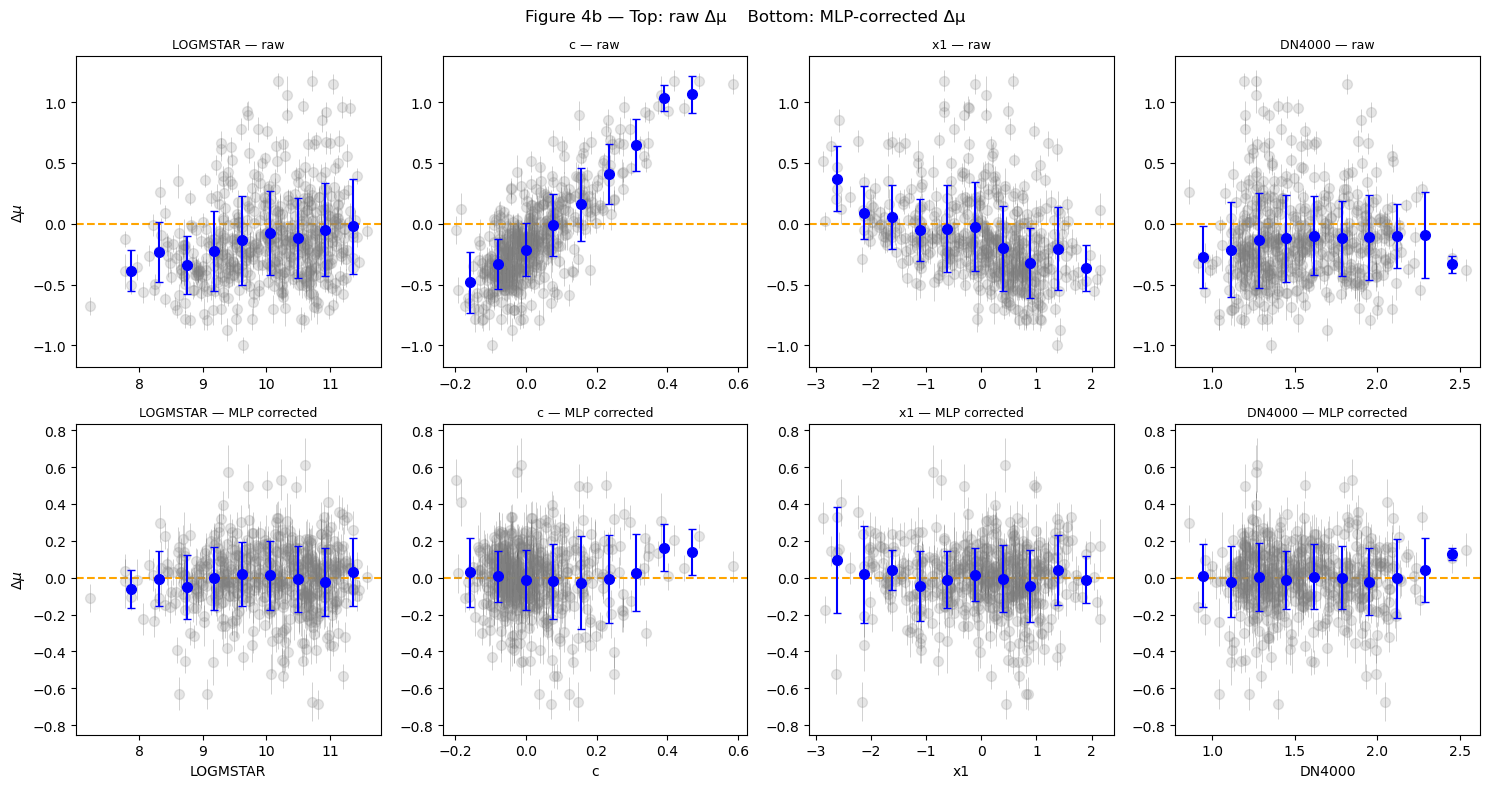

In [9]:
# --- Histogram comparison (Fig 4a) ---
nmad_raw = nmad(y.values, np.zeros_like(y.values))
sig_raw  = np.std(y.values)
sig_mlp  = np.std(y_corr_mlp)
nmad_mlp = 1.4826 * np.median(np.abs(y_corr_mlp))

bins = np.linspace(-0.6, 0.6, 40)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, vals, title, sigma, nm, color in zip(
    axes,
    [y.values,    y_corr_mlp],
    ['Raw Δμ',    'MLP corrected'],
    [sig_raw,     sig_mlp],
    [1.4826*np.median(np.abs(y.values)), nmad_mlp],
    ['grey',      'darkorange'],
):
    ax.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor='white', lw=0.4)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'{title}\n'
                 f'σ = {sigma:.4f}   NMAD = {nm:.4f} mag', fontsize=10)
    ax.set_xlabel(r'$\Delta\mu$ (mag)')

axes[0].set_ylabel('Count')
fig.suptitle('Figure 4 — Before/After Scatter Reduction (OOS cross-val predictions)')
plt.tight_layout()
plt.show()

# --- Before/after 2×4 grid (Fig 4b) — binned trends before and after ---
fig, axes = plt.subplots(2, 4, figsize=(15, 8), sharey=False)
cols_show = ['LOGMSTAR', 'c', 'x1', 'DN4000']

for col, ax_top, ax_bot in zip(cols_show, axes[0], axes[1]):
    scatter_with_errors(ax_top, col, nbins=nbins)
    ax_top.set_title(f'{col} — raw', fontsize=9)
    ax_top.set_xlabel('')

    scatter_with_errors(ax_bot, col, y_vals=y_corr_mlp, nbins=nbins)
    ax_bot.set_title(f'{col} — MLP corrected', fontsize=9)
    ax_bot.set_xlabel(col)

for ax in axes[:, 0]:
    ax.set_ylabel(r'$\Delta\mu$')

fig.suptitle('Figure 4b — Top: raw Δμ    Bottom: MLP-corrected Δμ')
plt.tight_layout()
plt.show()


---
## Table 1 — MLP Metrics

All metrics are computed on the held-out test set (20 %).  NMAD is the standard
SN cosmology scatter metric.  σ_raw and σ_corr are the standard deviations of
the residuals before and after ML correction (OOS).


In [10]:
def compute_metrics(y_true, y_pred, y_raw_full, y_corr_full, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2   = r2_score(y_true, y_pred)
    nm   = nmad(y_true, y_pred)
    sig_raw  = np.std(y_raw_full)
    sig_corr = np.std(y_corr_full)
    return dict(Model=label, MAE=mae, RMSE=rmse, NMAD=nm,
                R2=r2,
                sigma_raw=sig_raw, sigma_corr=sig_corr,
                delta_sigma=sig_raw - sig_corr)

rows = [
    compute_metrics(yte, yhat_mlp_te, y.values, y_corr_mlp, 'MLP (skopt)'),
]
table = pd.DataFrame(rows).set_index('Model')
print('Table 1 — MLP Performance')
print(table.to_string(float_format=lambda x: f'{x:.4f}'))


Table 1 — MLP Performance
               MAE   RMSE   NMAD     R2  sigma_raw  sigma_corr  delta_sigma
Model                                                                      
MLP (skopt) 0.1369 0.1851 0.1397 0.6780     0.3526      0.1780       0.1745


---
## SHAP Values

SHAP (SHapley Additive exPlanations) gives a per-SN attribution: for each
object, how much does each feature push the prediction up or down from the
baseline?

- **MLP**: `KernelExplainer` — approximation using Shapley sampling;
  evaluated on the first 80 test SNe to keep runtime under ~3 min.
  Increase `mlp_shap_n` for publication-quality plots.

**Beeswarm summary plot** — dots are individual SNe; colour = feature value;
horizontal position = SHAP value.


*(RF SHAP removed — MLP-only analysis)*


  0%|          | 0/80 [00:00<?, ?it/s]

MLP SHAP — beeswarm summary


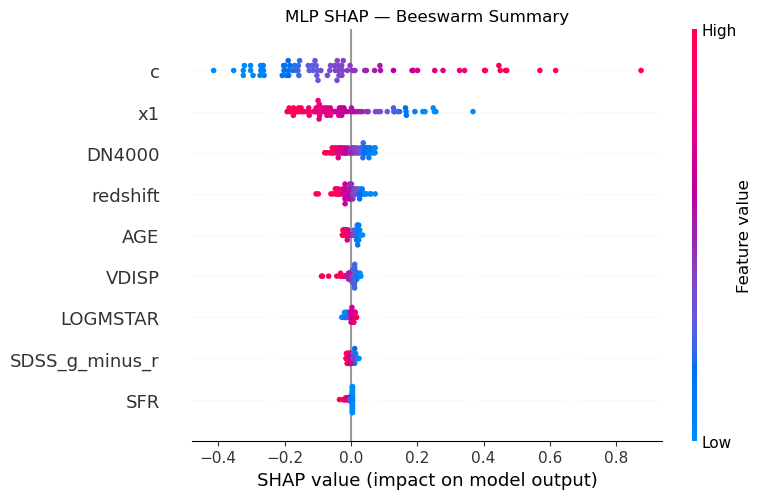

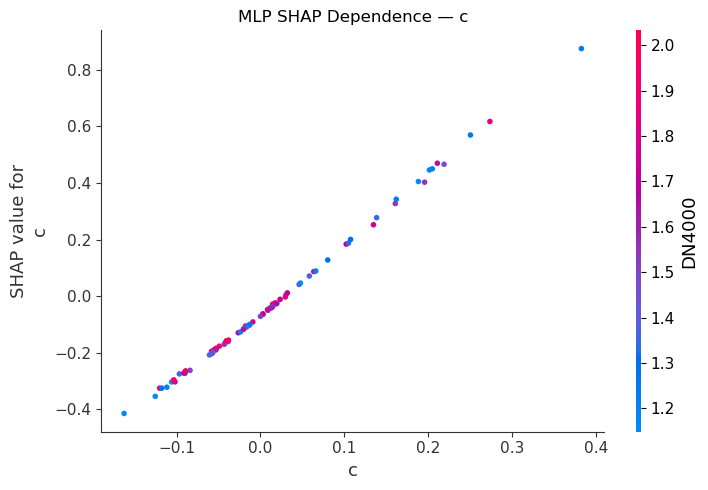

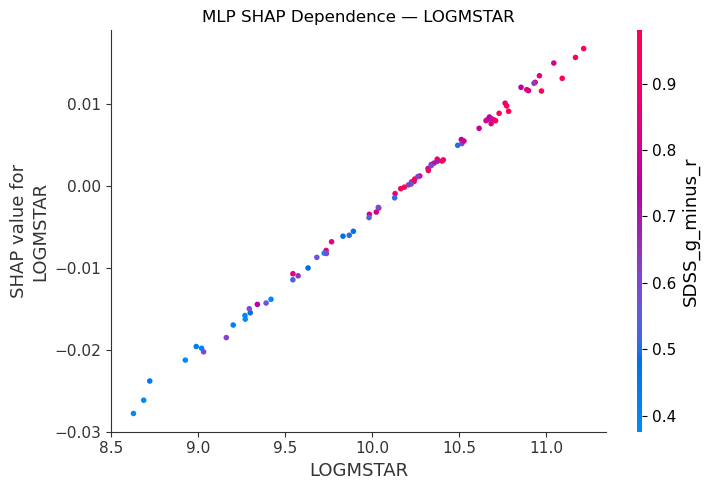

In [11]:
# ── MLP SHAP (KernelExplainer — approximation) ───────────────────────────────
# Wrap predict in a plain function so shap never tries to introspect the
# Pipeline object (known shap/sklearn compatibility bug: shap tries to set
# feature_names_in_=None on the Pipeline, which is a read-only property).
def _mlp_predict(X):
    return mlp_pipe.predict(X)

mlp_shap_n = 80
background = Xtr.sample(100, random_state=SEED)   # plain pandas sample
expl_mlp   = shap.KernelExplainer(_mlp_predict, background)
shap_mlp   = expl_mlp.shap_values(Xte.iloc[:mlp_shap_n], nsamples=200)

# Newer shap versions return an Explanation object — unwrap if needed
if hasattr(shap_mlp, 'values'):
    shap_mlp = shap_mlp.values

print('MLP SHAP — beeswarm summary')
shap.summary_plot(shap_mlp, Xte.iloc[:mlp_shap_n],
                  feature_names=feature_cols, show=False)
plt.title('MLP SHAP — Beeswarm Summary')
plt.tight_layout()
plt.show()

for feat in ['c', 'LOGMSTAR']:
    shap.dependence_plot(feat, shap_mlp, Xte.iloc[:mlp_shap_n],
                         feature_names=feature_cols,
                         interaction_index='auto', show=False)
    plt.title(f'MLP SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.show()

---
## 2-D Binned Residual Heatmaps

For each pair of host-galaxy properties, bin the sample onto a 2-D grid and
colour each cell by the mean Δμ.  Diagonal or saddle-point structure in the
heatmap is direct evidence of an **interaction effect** that a univariate Tripp
correction cannot capture — and that the MLP should be learning.

Key pairs:
- `LOGMSTAR × SFR` — classic age/environment degeneracy
- `LOGMSTAR × DN4000` — mass-age relation
- `c × LOGMSTAR` — colour-mass interaction (dust vs intrinsic)
- `SDSS_g_minus_r × AGE` — colour-age


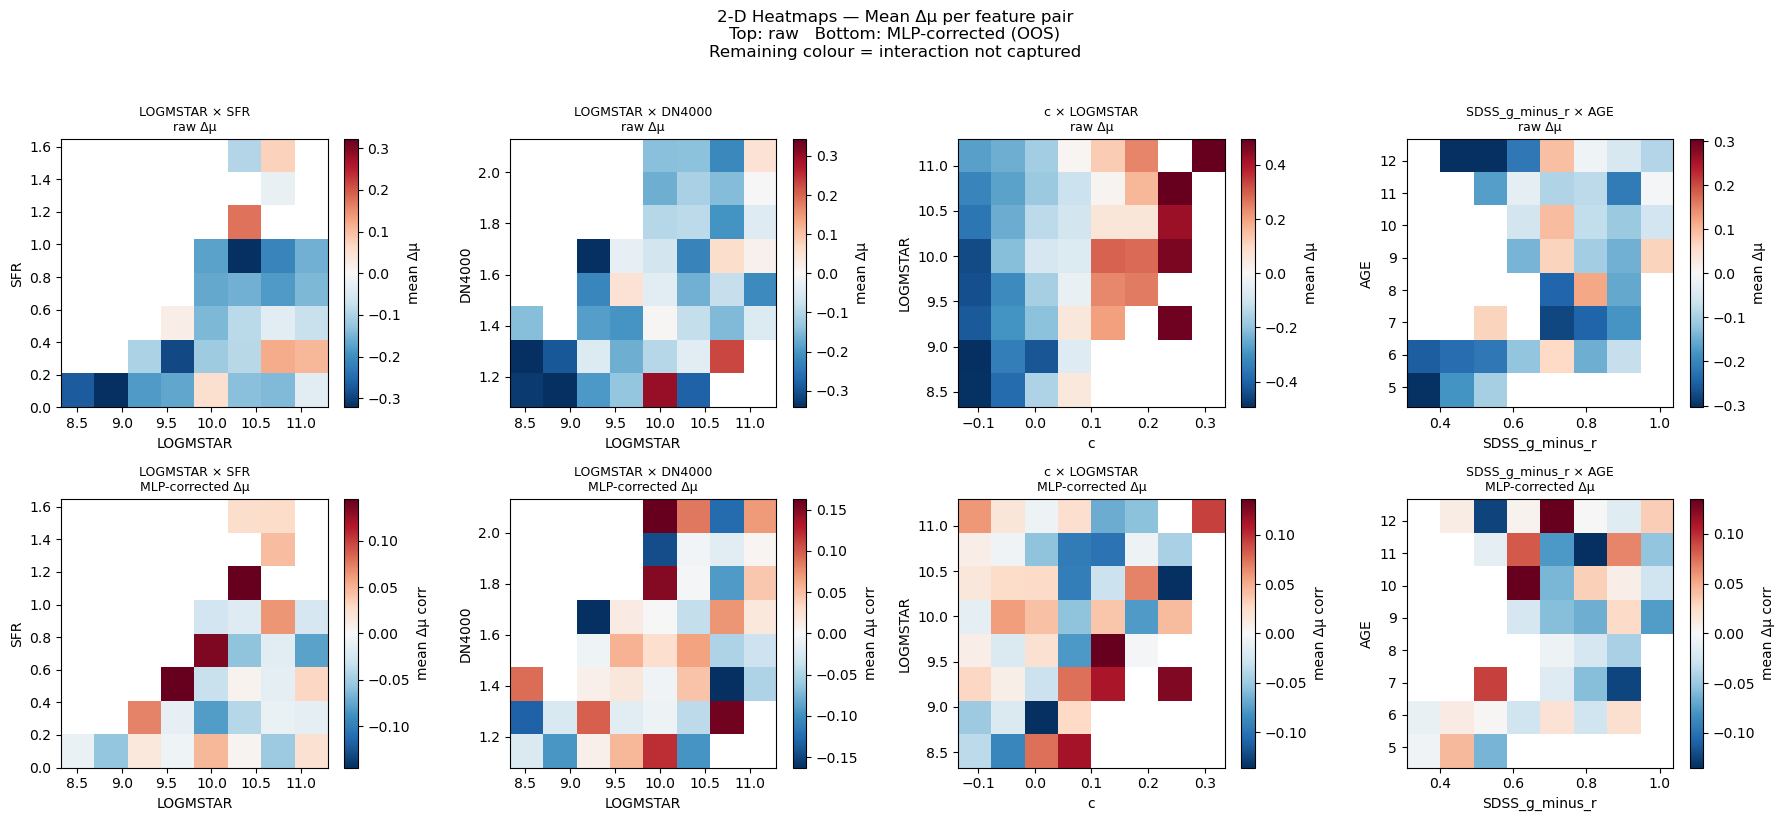

In [12]:
def heatmap_2d(ax, xcol, ycol, z_vals=None, nbins=8, cmap='RdBu_r', vabs=None):
    """Bin (xcol, ycol) into a grid; colour by mean z_vals (default: raw Δμ)."""
    xv = df[xcol].values
    yv = df[ycol].values
    zv = y.values if z_vals is None else np.asarray(z_vals)

    x_edges = np.linspace(np.nanpercentile(xv, 2), np.nanpercentile(xv, 98), nbins+1)
    y_edges = np.linspace(np.nanpercentile(yv, 2), np.nanpercentile(yv, 98), nbins+1)

    grid  = np.full((nbins, nbins), np.nan)
    count = np.zeros((nbins, nbins), dtype=int)
    for i in range(nbins):
        for j in range(nbins):
            mask = (
                (xv >= x_edges[i]) & (xv < x_edges[i+1]) &
                (yv >= y_edges[j]) & (yv < y_edges[j+1])
            )
            if mask.sum() >= 3:
                grid[j, i]  = np.mean(zv[mask])
                count[j, i] = mask.sum()

    vmax = vabs if vabs else np.nanpercentile(np.abs(grid[~np.isnan(grid)]), 95)
    im = ax.imshow(grid, origin='lower', aspect='auto', cmap=cmap,
                   vmin=-vmax, vmax=vmax,
                   extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    return im


pairs = [
    ('LOGMSTAR', 'SFR'),
    ('LOGMSTAR', 'DN4000'),
    ('c',        'LOGMSTAR'),
    ('SDSS_g_minus_r', 'AGE'),
]
titles = [
    'raw Δμ',
    'raw Δμ',
    'raw Δμ',
    'raw Δμ',
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (xcol, ycol) in enumerate(pairs):
    # Top row: raw residuals
    im = heatmap_2d(axes[0, col], xcol, ycol, z_vals=y.values, nbins=8)
    axes[0, col].set_title(f'{xcol} × {ycol}\nraw Δμ', fontsize=9)
    plt.colorbar(im, ax=axes[0, col], label='mean Δμ')

    # Bottom row: MLP-corrected residuals (OOS)
    im2 = heatmap_2d(axes[1, col], xcol, ycol, z_vals=y_corr_mlp, nbins=8)
    axes[1, col].set_title(f'{xcol} × {ycol}\nMLP-corrected Δμ', fontsize=9)
    plt.colorbar(im2, ax=axes[1, col], label='mean Δμ corr')

fig.suptitle('2-D Heatmaps — Mean Δμ per feature pair\n'
             'Top: raw   Bottom: MLP-corrected (OOS)\n'
             'Remaining colour = interaction not captured', y=1.02)
plt.tight_layout()
plt.show()

---
## ALE Plots (Accumulated Local Effects)

Partial dependence plots evaluate the model at feature combinations that may not
exist in the data (e.g. high mass + high SFR + young age).  For correlated features
like host-galaxy properties, this can produce misleading extrapolations.

**ALE plots** (Apley & Zhu 2020) avoid this by computing *local* perturbations
within small slices of the observed distribution, then accumulating them.

We show ALE for the MLP on the four most important features.


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


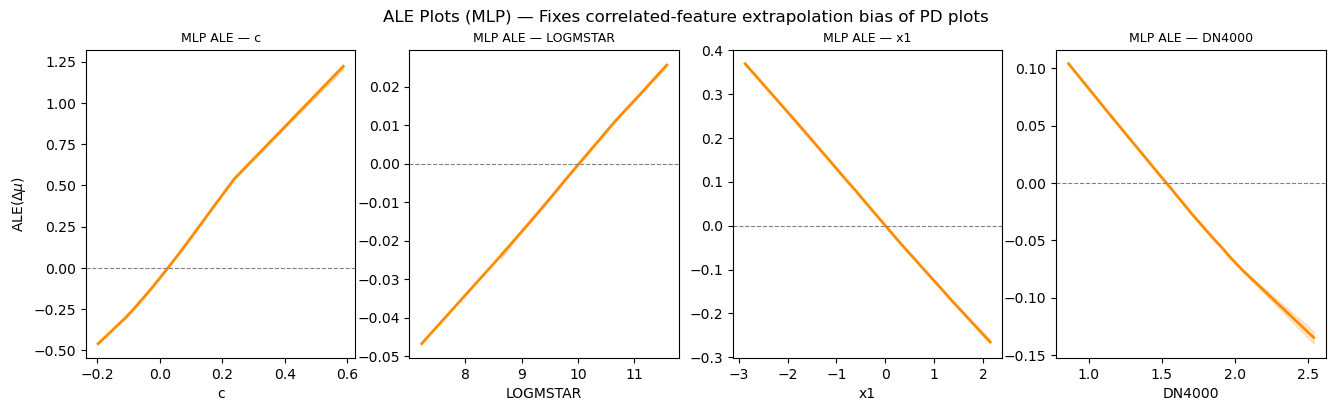

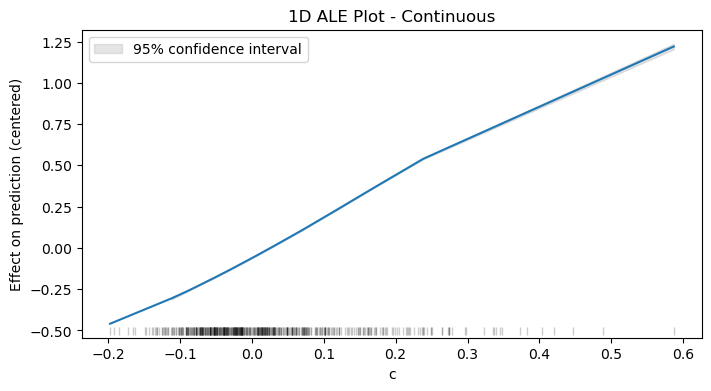

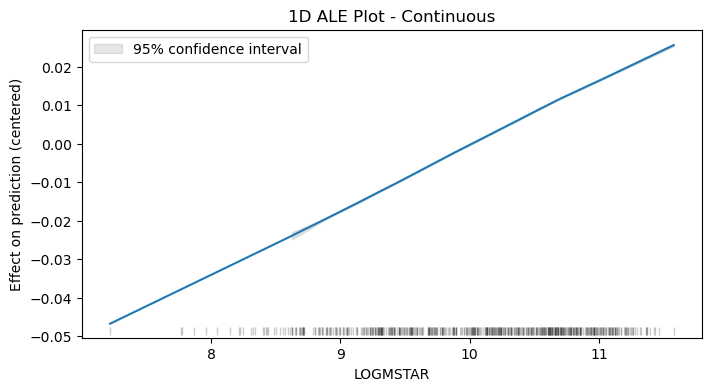

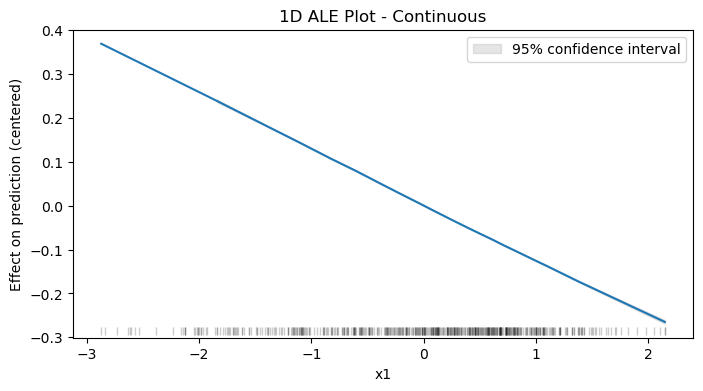

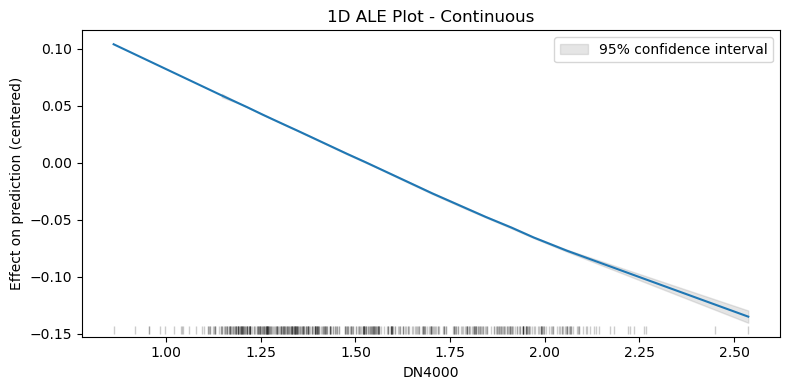

In [13]:
if not HAS_PYALE:
    print('PyALE not installed — skipping ALE plots.')
else:
    ale_features = ['c', 'LOGMSTAR', 'x1', 'DN4000']
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for col, feat in enumerate(ale_features):
        ax = axes[col]
        try:
            ale_eff = pyale(
                X=X[feature_cols].copy(),
                model=mlp_pipe,
                feature=[feat],
                grid_size=20,
                include_CI=True,
                C=0.95,
            )
            ax.plot(ale_eff.index, ale_eff['eff'],
                    color='darkorange', lw=2, label='MLP')
            if 'lowerCI_95%' in ale_eff.columns:
                ax.fill_between(
                    ale_eff.index,
                    ale_eff['lowerCI_95%'],
                    ale_eff['upperCI_95%'],
                    alpha=0.2, color='darkorange',
                )
        except Exception as e:
            ax.text(0.5, 0.5, str(e), transform=ax.transAxes,
                    ha='center', va='center', fontsize=7, wrap=True)
        ax.axhline(0, color='grey', lw=0.8, linestyle='--')
        ax.set_xlabel(feat)
        ax.set_title(f'MLP ALE — {feat}', fontsize=9)
        if col == 0:
            ax.set_ylabel(r'ALE($\Delta\mu$)')

    fig.suptitle('ALE Plots (MLP) — Fixes correlated-feature extrapolation bias of PD plots')
    plt.tight_layout()
    plt.show()


---
## Conditional Residual Histograms

Split the sample into sub-populations and compare the before/after residual
distributions per group.  This directly shows whether the MLP correction
eliminates the known host-galaxy biases rather than just reducing global scatter.

Splits:
1. **Mass step** — high vs low mass at log M★ = 10
2. **Passive vs star-forming** — Dn4000 ≥ 1.5 vs < 1.5


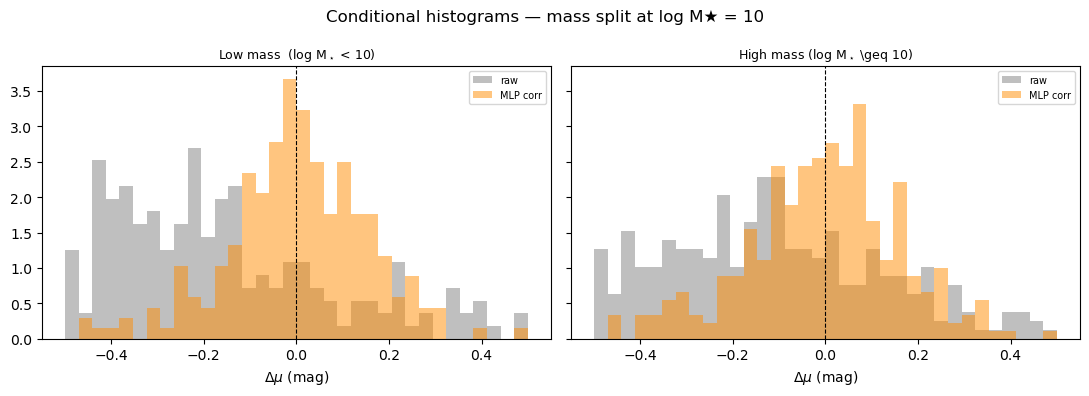

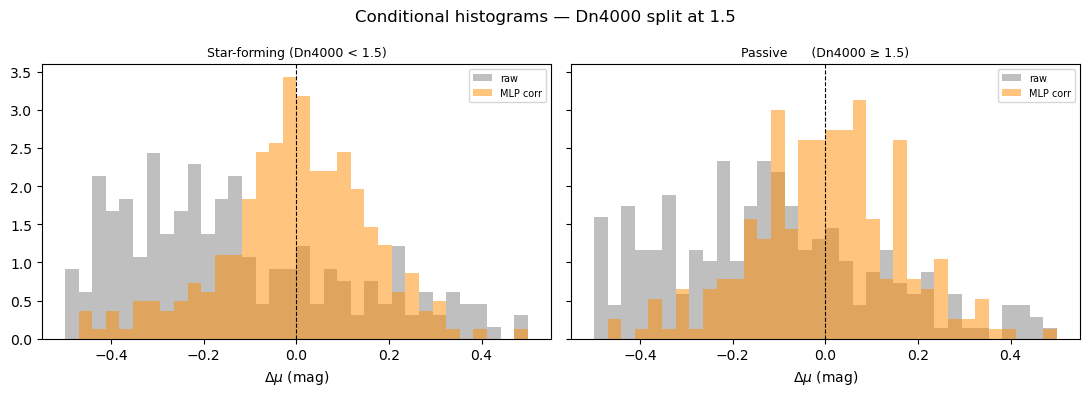

In [14]:
def cond_hist(ax, mask, label, bins, y_raw, y_corr_mlp):
    ax.hist(y_raw[mask],      bins=bins, alpha=0.5, color='grey',
            label='raw',          density=True)
    ax.hist(y_corr_mlp[mask], bins=bins, alpha=0.5, color='darkorange',
            label='MLP corr',     density=True)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel(r'$\Delta\mu$ (mag)')
    ax.legend(fontsize=7)


bins = np.linspace(-0.5, 0.5, 35)
y_raw = y.values

# ── Mass split ────────────────────────────────────────────────────────────────
mass_hi = df['LOGMSTAR'].values >= 10
mass_lo = ~mass_hi

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
cond_hist(axes[0], mass_lo, r'Low mass  (log M$_\star$ < 10)',
          bins, y_raw, y_corr_mlp)
cond_hist(axes[1], mass_hi, r'High mass (log M$_\star$ \geq 10)',
          bins, y_raw, y_corr_mlp)
fig.suptitle('Conditional histograms — mass split at log M★ = 10')
plt.tight_layout()
plt.show()

# ── Dn4000 split (passive vs star-forming) ────────────────────────────────────
passive     = df['DN4000'].values >= 1.5
star_form   = ~passive

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
cond_hist(axes[0], star_form, 'Star-forming (Dn4000 < 1.5)',
          bins, y_raw, y_corr_mlp)
cond_hist(axes[1], passive,   'Passive      (Dn4000 ≥ 1.5)',
          bins, y_raw, y_corr_mlp)
fig.suptitle('Conditional histograms — Dn4000 split at 1.5')
plt.tight_layout()
plt.show()


---
## Mass Step

The community benchmark for host-galaxy bias is the **mass step**: the difference
in mean Hubble residual between high- and low-mass hosts split at log M★ = 10.
The standard value in current surveys is ~0.06 mag.

We compute the step and its uncertainty (standard error on the mean difference)
before and after MLP correction.


Mass step at log M★ = 10.0
  N(high) = 315   N(low) = 235

  Raw Δμ                step = +0.1153 ± 0.0297 mag
  MLP-corrected         step = -0.0055 ± 0.0151 mag


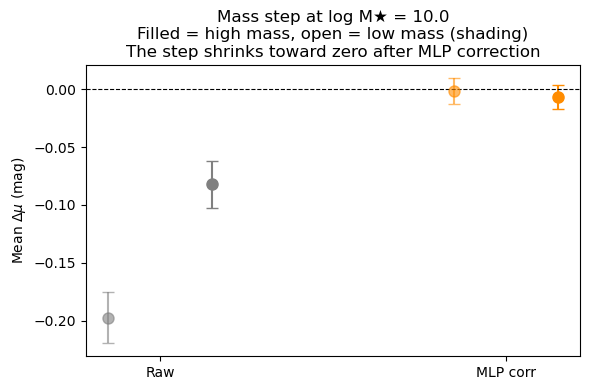

In [15]:
STEP_CUT = 10.0
mask_hi  = df['LOGMSTAR'].values >= STEP_CUT
mask_lo  = ~mask_hi


def mass_step(vals, mask_hi, mask_lo):
    """Return (step, uncertainty) where step = mean_hi - mean_lo."""
    hi, lo   = vals[mask_hi], vals[mask_lo]
    step     = np.mean(hi) - np.mean(lo)
    unc      = np.sqrt(np.var(hi)/len(hi) + np.var(lo)/len(lo))
    return step, unc


print(f'Mass step at log M★ = {STEP_CUT}')
print(f'  N(high) = {mask_hi.sum()}   N(low) = {mask_lo.sum()}')
print()

for label, vals in [
    ('Raw Δμ',          y.values),
    ('MLP-corrected',   y_corr_mlp),
]:
    step, unc = mass_step(vals, mask_hi, mask_lo)
    print(f'  {label:<20s}  step = {step:+.4f} ± {unc:.4f} mag')

# Visual: mean Δμ per group, before and after
fig, ax = plt.subplots(figsize=(6, 4))
groups = ['Raw', 'MLP corr']
vals_list = [y.values, y_corr_mlp]
colors = ['grey', 'darkorange']

for g_idx, (gname, vals, gc) in enumerate(zip(groups, vals_list, colors)):
    for b_idx, (bmask, blabel, bx) in enumerate([
        (mask_lo, 'low M', -0.15),
        (mask_hi, 'high M', +0.15),
    ]):
        mean = np.mean(vals[bmask])
        sem  = np.std(vals[bmask]) / np.sqrt(bmask.sum())
        x    = g_idx + bx
        ax.errorbar(x, mean, yerr=sem, fmt='o', color=gc,
                    markersize=8, capsize=4,
                    alpha=(0.6 if b_idx == 0 else 1.0))

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups)
ax.set_ylabel(r'Mean $\Delta\mu$ (mag)')
ax.set_title(f'Mass step at log M★ = {STEP_CUT}\n'
             'Filled = high mass, open = low mass (shading)\n'
             'The step shrinks toward zero after MLP correction')
plt.tight_layout()
plt.show()
